# Project 2 -- Ansh Tandon

**TA Help:** John Smith, Alice Jones

- Help with figuring out how to write a function.
    
**Collaboration:** Friend1, Friend2
    
- Helped figuring out how to load the dataset.
- Helped debug error with my plot.

## Question 1

In [10]:
import pandas as pd

data = pd.read_csv('/anvil/projects/tdm/data/mnist/mnist_train.csv')

In [11]:
print(data.head())

   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [12]:
print(data.shape)

(60000, 785)


Question 1a and 1b:
From the shape of the dataset, I see it is 60000 rows and there are 785 columns that are present. This means there are 60,000 images and then also 784 pixel features. Based on the dataset, I see that there is a label for each of the images and that corresponds to what is evident from numbers 0 to 9 which was within the MNIST dataset when displaying the images in the previous lab. Also, I do see that most of the values within the data set are 0s, which represent that all of those pixels represent a black color. This is because the image must have a background that is black especially in the top left and bottom right, so there is no assigned digit in the ones displayed in the head. It is apparant that the pixel formatting is based on the row and column, which starts from 1x1 and goes all the way till 28x28 as in the bottom right.

## Question 2

In [13]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np

In [14]:
class MNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # First column of a row idx is the label
        label = self.data.iloc[idx, 0]
        # Get all remainder of the row (columns - pixels) and returns 1D array through .values
        # 8bit unsigned integers allow visual display of grayscale images. It has 0-255 for the 256 different intensity levels
        pixels = self.data.iloc[idx, 1:].values.astype(np.uint8)
        # Convert into 2D array (28x28)
        image = pixels.reshape(28, 28)

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
transform = transforms.Compose([transforms.ToTensor(),   # converts image to tensor [0,1]
                                 transforms.Normalize((0.5,), (0.5,))])  # normalize to [-1,1]

train_dataset = MNISTDataset('/anvil/projects/tdm/data/mnist/mnist_train.csv', transform=transform)
load_train = DataLoader(train_dataset, batch_size=64, shuffle=True)

# test_dataset
# now i am creating the mnist dataset for the test dataset within mnist
test_dataset = MNISTDataset('/anvil/projects/tdm/data/mnist/mnist_test.csv', transform=transform)

# load_test
# utilizing dataloader within torch to load later when i do the training loop with a batch size of 64
load_test = DataLoader(test_dataset, batch_size=64, shuffle=True)

# Print training and test dataset size
# now i am printing the length of the train and test datasets
print(f"Training Dataset Size = {len(train_dataset)}") # this is 60000
print(f"Test Dataset Size = {len(test_dataset)}") # this is 10000

Training Dataset Size = 60000
Test Dataset Size = 10000


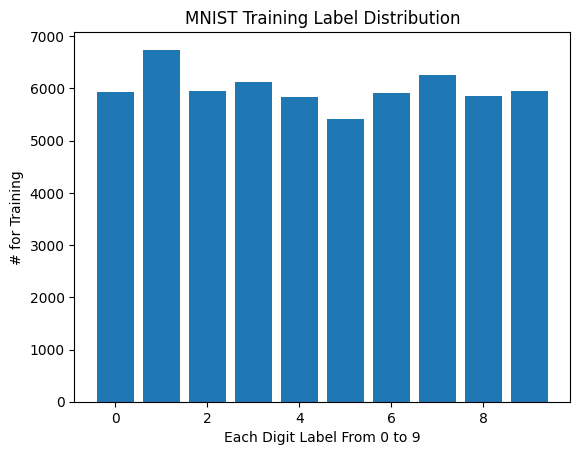

In [16]:
import matplotlib.pyplot as plt

labels = []
# Iterate through each sample in train_dataset
# Obtain the label (digits 0-9) and add to the list
for image, label in train_dataset:
    labels.append(label)

# Create Pandas Series then count unique value occurences and sort in digit order
# now i will create the pandas series by utilizng the labels that were appending and the pandas function 
my_series = pd.Series(labels)
# next i will count the occurences with the labels with using group by and size
my_group = my_series.groupby(my_series).size()
# finally i will sort each of the labels based on the index
my_labels = my_group.sort_index()


# Create plot (can do it in Pandas)
# first i will create the plt figure and then have the labels to get the index and values
plt.figure()
my_index = my_labels.index # getting the indexes from the labels
my_counts = my_labels.values # getting the values that are the counts from the labels
plt.bar(my_index, my_counts) # creating a bar plot with the indexes and the counts
plt.xlabel("Each Digit Label From 0 to 9")
plt.ylabel("# for Training")
plt.title("MNIST Training Label Distribution")
plt.show()

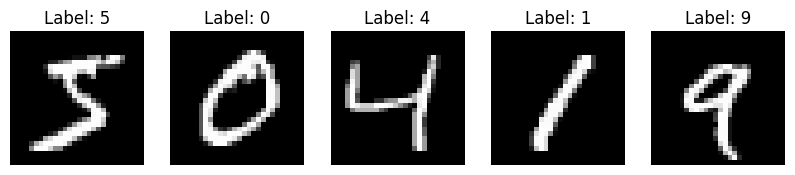

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(10, 5))

for i in range(5):
  image, label = train_dataset[i]
  pic = image.squeeze().numpy()
  axes[i].imshow(pic, cmap='gray')
  axes[i].set_title(f"Label: {label}")
  axes[i].axis('off')
plt.show()

Question 2c:

The above graph tells the distribution of the amount of training samples based on each of the digit labels from 0 to 9.

## Question 3

In [18]:
import torch.nn as nn
import torch.nn.functional as F

In [19]:
class cnn(nn.Module):
  def __init__(self):
    super().__init__()

    # 1st convolutional layer
    self.conv1 = nn.Conv2d(1,8,kernel_size=3, stride=1, padding=1)

    # 2nd convolutional layer
    # now i will go ahead and create the second convolutional layer, which will be 8 channels from the first layer
    # but then for the output is 16 based on the hadnout
    self.conv2 = nn.Conv2d(8,16,kernel_size=3, stride=1, padding=1)

    # fully connected layer
    # since here i wil create the fully connected linear layer to properly complete the layer
    # based on the handout the size is 16, 7, 7 as that is the image size so will multiply them together
    # also since the ouput size is 0-9 digits that means it is a size of 10
    self.fc1 = nn.Linear(16*7*7,10)

  def forward(self, x):
    # 1st convolutional layer with ReLU and max pooling
    x = F.relu(self.conv1(x))
    x = F.max_pool2d(x,2,2)

    # 2nd convolutional layer
    # now for the second convolution layer i will use the F relu like the above and create the max pool2d similar with 2,2
    x = F.relu(self.conv2(x))
    x = F.max_pool2d(x,2,2)

    # flatten
    x = x.reshape(x.shape[0], -1)

    # fully connected layer
    x = self.fc1(x)
    return x

In [20]:
# from this i will properly test the basic cnn that i created
my_cnn = cnn()

In [21]:
print(my_cnn)

cnn(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


Question 3c: The difference between the convolution and cross correlation is that within the convolution, the kernel essential flips the input where the rows and the columns are in essense reversed before being applied. However, within cross-correlation, the kernel is directly applied without any sliding. Regardless of whether or not a CNN is valid, it still works regardless because the kernels are symmetric. Not only that, when the model is getting trained, the CNN will accordingly adjust the weights of the network through backpropogation, so those kernel values will change.
Question 3d: Max pooling is essentially used in order to minimize the input through utilizing a sliding window that is a 2 by 2 to get the maximum value, and it ensures that the noise is reduced of values that are smaller and not that relavant. Average pooling is when you reduce the spatial size for the feature maps that you with calculating the mean for all of the values within that particular window. In general, this is helpful to ensure that the features actually indicate a pattern. The difference between the two is that the max pooling works on taking the maximium value, while the average pooling gives equal consideration for all of those weights. Because of this, it is better to do max pooling as you can ensure you have the features that are the strongest features that are closely resembling what that digit shape is within the MNIST dataset.
Question 3e: The difference between a convolutional layer and a fully connected layer is that a convolutional layer is a layer that detects local patterns through applying the particular filter across the input and the weights, and essentially it is looking at small aspects of the image to learn patterns. The fully connected layer is when every input is connected to the output, and each connection that is theer has their own respective weight.

## Question 4

In [22]:
import torch
import torch.optim as optim

device = torch.device("cpu")
model = cnn().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # adding progress bar
    for images, labels in tqdm(load_train, desc=f'Epoch {epoch+1}/{epochs}'):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        output = model(images)
        loss = criterion(output, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(load_train)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Epoch 1/5: 100%|██████████| 938/938 [00:14<00:00, 62.71it/s]


Epoch [1/5], Loss: 0.2673


Epoch 2/5: 100%|██████████| 938/938 [00:13<00:00, 67.51it/s]


Epoch [2/5], Loss: 0.0756


Epoch 3/5: 100%|██████████| 938/938 [00:14<00:00, 64.14it/s]


Epoch [3/5], Loss: 0.0560


Epoch 4/5: 100%|██████████| 938/938 [00:13<00:00, 68.78it/s]


Epoch [4/5], Loss: 0.0464


Epoch 5/5: 100%|██████████| 938/938 [00:13<00:00, 68.51it/s]

Epoch [5/5], Loss: 0.0409


Question 4b: The purpose of running multiple epochs is helpful as it ensures that the model can go through the entire dataset multiple times. This helps with ensuring that the weights can be adjusted accordingly and then is able to better recognize patterns accordingly. When you increase the number of epochs, the model will actually start to take the training data exactly how it is without really learning any general patterns, and this can cause overfitting with the model. However, if you decrease the number of epochs, the model will not learn enough and will lead to underfitting as it was not able to learn the patterns accordingly.
Question 4c: In terms of the forward pass, it is when the input data is sent into the network and then it produces an output. Within the forward pass, the steps look like first moving by each layer that is within the model, and then with utilizing the existing weights, it can make a prediction. Therefore, once the model goes through those layers it goes to the fully connected layers and that is where the classification is done. With respect to the backward pass, it is done after the loss is calculated and during the step, the network is able to figure out what each of the weights contribute to the error. And then all of this goes through the network and then it helps to determine how to reduce the loss.
Question 4d: The loss.backward() function essentially works to calculate how much the weights within the network contribute to the error that is present within the model, and it is able to do so by computing gradients to tell the direction and how strongly each weight should be adjusted in order to minimize the loss. In terms of the optimizer.step() function works towards using the gradients that were computed in order to actually update the weights, and this is done to ensure that the model can overall make better decisions.

## Question 5

In [24]:
def calculate_accuracy(model, data_loader, device):
    # Set to evaluation mode
    model.eval()

    # Initialize counters
    correct = 0
    total = 0

    with torch.no_grad():
        # Iterate through all batches
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            # torch.max will return (max, max index). We are getting the predicted index.
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Get percent accuracy
    return 100*correct/total

calculate_accuracy(model, load_test, device)

98.68

In [37]:
# now i will go ahead and utilize average pooling and then compute the accuracy for this
# i will go ahead and refactor my existing code

class cnn_new(nn.Module):
  def __init__(self):
    super().__init__()

    # 1st convolutional layer
    self.conv1 = nn.Conv2d(1,8,kernel_size=3, stride=1, padding=1)

    # 2nd convolutional layer
    # now i will go ahead and create the second convolutional layer, which will be 8 channels from the first layer
    # but then for the output is 16 based on the hadnout
    self.conv2 = nn.Conv2d(8,16,kernel_size=3, stride=1, padding=1)

    # fully connected layer
    # since here i wil create the fully connected linear layer to properly complete the layer
    # based on the handout the size is 16, 7, 7 as that is the image size so will multiply them together
    # also since the ouput size is 0-9 digits that means it is a size of 10
    self.fc1 = nn.Linear(16*7*7,10)

  def forward(self, x):
    # 1st convolutional layer with ReLU and max pooling
    x = F.relu(self.conv1(x))
    x = F.avg_pool2d(x,2,2)

    # 2nd convolutional layer
    # now for the second convolution layer i will use the F relu like the above and create the max pool2d similar with 2,2
    x = F.relu(self.conv2(x))
    x = F.avg_pool2d(x,2,2) # here i have changed my implementation in order to use the average pooling

    # flatten
    x = x.reshape(x.shape[0], -1)

    # fully connected layer
    x = self.fc1(x)
    return x

In [38]:
# utilizing my existing code from question 4
device = torch.device("cpu")
model_new = cnn_new().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_new.parameters(), lr=0.001)

In [39]:
epochs = 5

for epoch in range(epochs):
    model_new.train()
    running_loss = 0.0

    # adding progress bar
    for images, labels in tqdm(load_train, desc=f'Epoch {epoch+1}/{epochs}'):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        output = model_new(images)
        loss = criterion(output, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(load_train)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Epoch 1/5: 100%|██████████| 938/938 [00:13<00:00, 68.99it/s]


Epoch [1/5], Loss: 0.3822


Epoch 2/5: 100%|██████████| 938/938 [00:13<00:00, 69.36it/s]


Epoch [2/5], Loss: 0.1135


Epoch 3/5: 100%|██████████| 938/938 [00:13<00:00, 68.58it/s]


Epoch [3/5], Loss: 0.0762


Epoch 4/5: 100%|██████████| 938/938 [00:13<00:00, 69.43it/s]


Epoch [4/5], Loss: 0.0611


Epoch 5/5: 100%|██████████| 938/938 [00:14<00:00, 66.69it/s]

Epoch [5/5], Loss: 0.0532


In [40]:
calculate_accuracy(model_new, load_test, device)

98.51

Markdown notes and sentences and analysis written here.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.